# Check cuda

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100 80GB PCIe


In [2]:
import torch_geometric
print(torch_geometric.__version__)

2.7.0


# Load log and extract traces

In [3]:
import pandas as pd
from pm4py.objects.log.importer.xes import importer as xes_importer
from datetime import datetime

def extract_traces(log_path):
    """
    Load an event log and extract all traces + unique activities.

    Parameters:
        log_path (str): Path to the event log file

    Returns:
        tuple:
            - list: traces (with full event data)
            - list: unique activities in the log
    """
    
    log = xes_importer.apply(log_path)

    result = []
    activities = set()  # to store unique activity names

    for trace in log:
        trace_info = {
            "trace_attributes": dict(trace.attributes),
            "events": []
        }

        for event in trace:
            event_dict = dict(event)
            trace_info["events"].append(event_dict)

            # Collect activity name
            if "concept:name" in event_dict:
                activities.add(event_dict["concept:name"])

        result.append(trace_info)

    return result, activities

def truncate_datetime(dt, level):
    """
    Truncate a datetime object to a specified level.

    level:
    "year", "month", "day", "hour", "minute", "second"
    """

    levels = ["year", "month", "day", "hour", "minute", "second"]

    if level not in levels:
        raise ValueError(f"Invalid level. Choose from {levels}")

    # Default values for missing components
    values = {
        "year": dt.year,
        "month": 1,
        "day": 1,
        "hour": 0,
        "minute": 0,
        "second": 0
    }

    # Fill values up to desired level
    for l in levels:
        values[l] = getattr(dt, l)
        if l == level:
            break

    return datetime(
        values["year"],
        values["month"],
        values["day"],
        values["hour"],
        values["minute"],
        values["second"],
        tzinfo=dt.tzinfo
    )

def truncate_trace_timestamps(trace, level):
    """
    Apply datetime truncation to all events in a trace.

    Parameters:
        trace (dict): Trace with 'trace_attributes' and 'events'
        level (str): Truncation level (year, month, day, hour, minute, second, none)

    Returns:
        dict: New trace with truncated timestamps
    """

    if level == "none":
        return trace

    # Copy trace structure (avoid mutating original)
    new_trace = {
        "trace_attributes": dict(trace["trace_attributes"]),
        "events": []
    }

    for event in trace["events"]:
        new_event = dict(event)

        if "time:timestamp" in new_event:
            new_event["time:timestamp"] = truncate_datetime(
                new_event["time:timestamp"], level
            )

        new_trace["events"].append(new_event)

    return new_trace

In [4]:
path = "logs/BPI_Challenge_2012.xes"
traces, activities = extract_traces(path)

parsing log, completed traces ::   0%|          | 0/13087 [00:00<?, ?it/s]

In [5]:
activities

{'A_ACCEPTED',
 'A_ACTIVATED',
 'A_APPROVED',
 'A_CANCELLED',
 'A_DECLINED',
 'A_FINALIZED',
 'A_PARTLYSUBMITTED',
 'A_PREACCEPTED',
 'A_REGISTERED',
 'A_SUBMITTED',
 'O_ACCEPTED',
 'O_CANCELLED',
 'O_CREATED',
 'O_DECLINED',
 'O_SELECTED',
 'O_SENT',
 'O_SENT_BACK',
 'W_Afhandelen leads',
 'W_Beoordelen fraude',
 'W_Completeren aanvraag',
 'W_Nabellen incomplete dossiers',
 'W_Nabellen offertes',
 'W_Valideren aanvraag',
 'W_Wijzigen contractgegevens'}

In [6]:
traces[0]

{'trace_attributes': {'REG_DATE': datetime.datetime(2011, 10, 1, 0, 38, 44, 546000, tzinfo=datetime.timezone.utc),
  'concept:name': '173688',
  'AMOUNT_REQ': '20000'},
 'events': [{'org:resource': '112',
   'lifecycle:transition': 'COMPLETE',
   'concept:name': 'A_SUBMITTED',
   'time:timestamp': datetime.datetime(2011, 10, 1, 0, 38, 44, 546000, tzinfo=datetime.timezone.utc)},
  {'org:resource': '112',
   'lifecycle:transition': 'COMPLETE',
   'concept:name': 'A_PARTLYSUBMITTED',
   'time:timestamp': datetime.datetime(2011, 10, 1, 0, 38, 44, 880000, tzinfo=datetime.timezone.utc)},
  {'org:resource': '112',
   'lifecycle:transition': 'COMPLETE',
   'concept:name': 'A_PREACCEPTED',
   'time:timestamp': datetime.datetime(2011, 10, 1, 0, 39, 37, 906000, tzinfo=datetime.timezone.utc)},
  {'org:resource': '112',
   'lifecycle:transition': 'SCHEDULE',
   'concept:name': 'W_Completeren aanvraag',
   'time:timestamp': datetime.datetime(2011, 10, 1, 0, 39, 38, 875000, tzinfo=datetime.timezone.u

In [7]:
truncate_trace_timestamps(traces[0], "second")

{'trace_attributes': {'REG_DATE': datetime.datetime(2011, 10, 1, 0, 38, 44, 546000, tzinfo=datetime.timezone.utc),
  'concept:name': '173688',
  'AMOUNT_REQ': '20000'},
 'events': [{'org:resource': '112',
   'lifecycle:transition': 'COMPLETE',
   'concept:name': 'A_SUBMITTED',
   'time:timestamp': datetime.datetime(2011, 10, 1, 0, 38, 44, tzinfo=datetime.timezone.utc)},
  {'org:resource': '112',
   'lifecycle:transition': 'COMPLETE',
   'concept:name': 'A_PARTLYSUBMITTED',
   'time:timestamp': datetime.datetime(2011, 10, 1, 0, 38, 44, tzinfo=datetime.timezone.utc)},
  {'org:resource': '112',
   'lifecycle:transition': 'COMPLETE',
   'concept:name': 'A_PREACCEPTED',
   'time:timestamp': datetime.datetime(2011, 10, 1, 0, 39, 37, tzinfo=datetime.timezone.utc)},
  {'org:resource': '112',
   'lifecycle:transition': 'SCHEDULE',
   'concept:name': 'W_Completeren aanvraag',
   'time:timestamp': datetime.datetime(2011, 10, 1, 0, 39, 38, tzinfo=datetime.timezone.utc)},
  {'concept:name': 'W_Comp

## Trace visualization 

In [8]:
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt

def trace_to_graph(trace):
    """
    Convert a trace into a DAG based on timestamp ordering.
    Events with identical timestamps are treated as a "block":
        - each event has its own node
        - all events in the block connect from same previous layer nodes
        - all events connect to same next layer nodes
    """
    
    G = nx.DiGraph()
    
    # Step 1: group events by timestamp
    time_groups = defaultdict(list)
    for event in trace["events"]:
        ts = event.get("time:timestamp")
        if ts is not None:
            time_groups[ts].append(event)
    
    # Step 2: sort timestamps
    sorted_times = sorted(time_groups.keys())
    
    # Keep track of nodes in the previous layer
    previous_nodes = []
    
    # Step 3: create nodes and connect edges layer by layer
    for ts in sorted_times:
        events = time_groups[ts]
        current_nodes = []
        
        # Create a node for each event
        for i, event in enumerate(events):
            # Node ID = timestamp index + event index
            node_id = f"{ts.isoformat()}_{i}"
            G.add_node(node_id, timestamp=ts, event=event, activity=event.get("concept:name"))
            current_nodes.append(node_id)
        
        # Connect previous layer nodes → all current nodes
        for prev in previous_nodes:
            for curr in current_nodes:
                G.add_edge(prev, curr)
        
        # Update previous_nodes for next iteration
        previous_nodes = current_nodes
    
    return G


def visualize_block(G):
    # Layer nodes by timestamp
    layers = sorted(set(nx.get_node_attributes(G, "timestamp").values()))
    pos = {}
    
    for layer_index, ts in enumerate(layers):
        # nodes in this layer
        nodes = [n for n, d in G.nodes(data=True) if d["timestamp"] == ts]
        for i, node in enumerate(nodes):
            pos[node] = (layer_index, -i)  # horizontal timeline, stack concurrent nodes vertically
    
    labels = {n: G.nodes[n]["activity"] for n in G.nodes}
    
    plt.figure(figsize=(20, 4))
    nx.draw(G, pos, with_labels=False, node_size=2000, node_color="lightblue")
    nx.draw_networkx_labels(G, pos, labels)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", width=2)
    plt.title("Trace Graph (Block-Style for Same Timestamp)")
    plt.axis("off")
    plt.show()

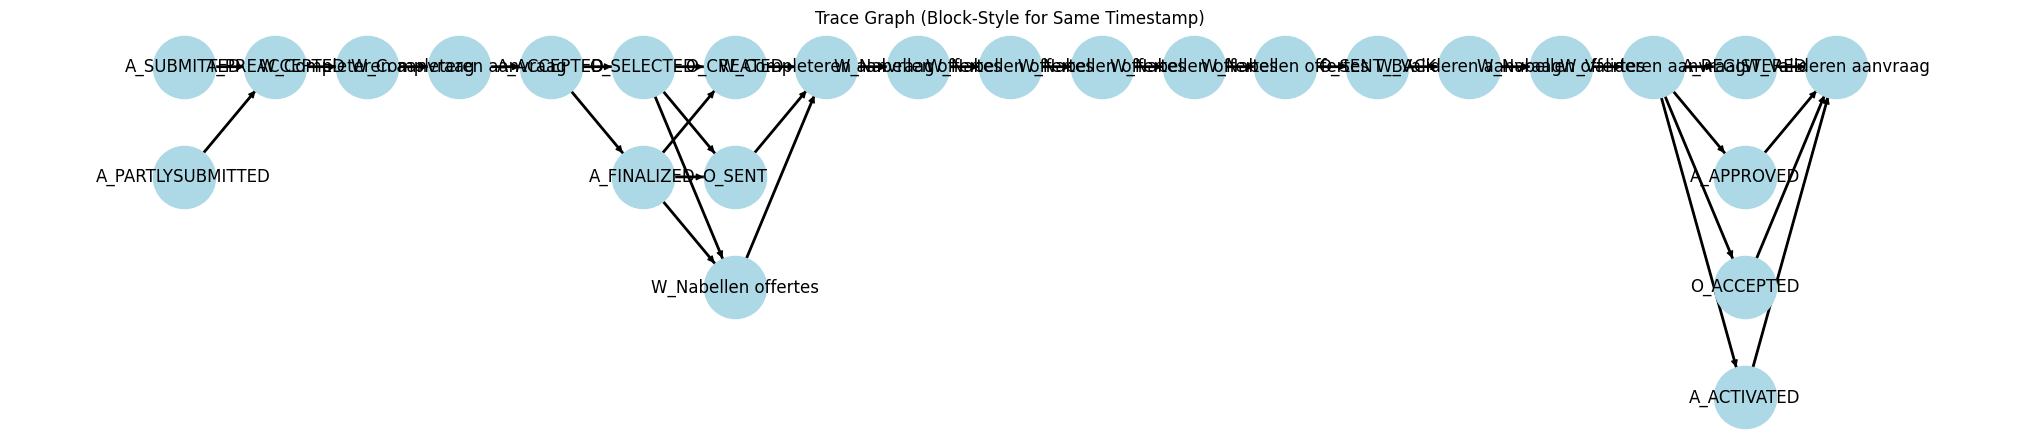

In [9]:
example = truncate_trace_timestamps(traces[0], "second")
G = trace_to_graph(example)
visualize_block(G)

# Create graph datasets

In [10]:
import torch
from torch_geometric.data import Data, Batch
from collections import defaultdict
from tqdm import tqdm

def truncate_datetime(dt, level):
    """
    Truncate a datetime object to a specified level.

    level:
    "year", "month", "day", "hour", "minute", "second"
    """

    levels = ["year", "month", "day", "hour", "minute", "second"]

    if level not in levels:
        raise ValueError(f"Invalid level. Choose from {levels}")

    # Default values for missing components
    values = {
        "year": dt.year,
        "month": 1,
        "day": 1,
        "hour": 0,
        "minute": 0,
        "second": 0
    }

    # Fill values up to desired level
    for l in levels:
        values[l] = getattr(dt, l)
        if l == level:
            break

    return datetime(
        values["year"],
        values["month"],
        values["day"],
        values["hour"],
        values["minute"],
        values["second"],
        tzinfo=dt.tzinfo
    )

def truncate_trace_timestamps(trace, level):
    """
    Apply datetime truncation to all events in a trace.

    Parameters:
        trace (dict): Trace with 'trace_attributes' and 'events'
        level (str): Truncation level (year, month, day, hour, minute, second, none)

    Returns:
        dict: New trace with truncated timestamps
    """

    if level == "none":
        return trace

    # Copy trace structure (avoid mutating original)
    new_trace = {
        "trace_attributes": dict(trace["trace_attributes"]),
        "events": []
    }

    for event in trace["events"]:
        new_event = dict(event)

        if "time:timestamp" in new_event:
            new_event["time:timestamp"] = truncate_datetime(
                new_event["time:timestamp"], level
            )

        new_trace["events"].append(new_event)

    return new_trace

# ---------------------------
# 1. Prefix graph generator
# ---------------------------
def trace_to_pyg_prefixes(trace, activity_to_idx):

    dataset = []

    # Group by timestamp
    time_groups = defaultdict(list)
    for event in trace["events"]:
        ts = event.get("time:timestamp")
        if ts is not None:
            time_groups[ts].append(event)

    sorted_times = sorted(time_groups.keys())

    # Global storage (grows with prefixes)
    node_activities = []
    node_timestamps = []
    edge_list = []
    edge_attr_list = []

    previous_node_indices = []

    for t_idx in range(len(sorted_times) - 1):
        ts = sorted_times[t_idx]
        next_ts = sorted_times[t_idx + 1]

        current_node_indices = []

        # --- Add nodes ---
        for event in time_groups[ts]:
            node_idx = len(node_activities)

            node_activities.append(event.get("concept:name"))
            node_timestamps.append(ts)

            current_node_indices.append(node_idx)

        # --- Add edges ---
        for prev in previous_node_indices:
            for curr in current_node_indices:
                delta = (
                    node_timestamps[curr] - node_timestamps[prev]
                ).total_seconds()

                edge_list.append((prev, curr))
                edge_attr_list.append(delta)

        # --- Build PyG graph for this prefix ---
        indices = torch.tensor(
            [activity_to_idx[a] for a in node_activities]
        )

        x = torch.eye(len(activity_to_idx))[indices].float()

        if len(edge_list) > 0:
            edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
            edge_attr = torch.tensor(edge_attr_list, dtype=torch.float).unsqueeze(1)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_attr = torch.empty((0, 1))

        # --- Target ---
        y = torch.zeros(len(activity_to_idx))
        for event in time_groups[next_ts]:
            act = event.get("concept:name")
            y[activity_to_idx[act]] = 1.0

        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=y.unsqueeze(0)
        )

        dataset.append(data)

        previous_node_indices = current_node_indices

    return dataset

# ---------------------------
# 2. Full pipeline
# ---------------------------
def traces_to_pyg_list(traces, activities, truncation_level):
    """
    Convert traces into prefix-based PyG dataset with targets
    """

    activity_to_idx = {act: i for i, act in enumerate(activities)}

    all_graphs = []

    for trace in tqdm(traces, desc="Processing traces"):
        truncated_trace = truncate_trace_timestamps(trace,truncation_level)
        prefix_graphs = trace_to_pyg_prefixes(truncated_trace, activity_to_idx)
        all_graphs.extend(prefix_graphs)

    #batch = Batch.from_data_list(all_graphs)

    return all_graphs, activity_to_idx

# Train and evaluate

In [11]:
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
import torch
import torch.nn as nn
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.metrics import f1_score
import numpy as np

# ---------------------------
# Simple GNN
# ---------------------------
class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        return self.lin(x)  # logits

# ---------------------------
# Helper function for metrics and evaluation
# ---------------------------
def compute_metrics(preds, targets):
    if len(targets) == 0:
        return 0.0, 0.0
    exact = np.all(preds == targets, axis=1).mean()
    f1 = f1_score(targets, preds, average="micro")
    return exact, f1

def compute_occurrence_metrics(preds_all, targets_all):
    """
    Compute metrics for predictions split by single-activity and multi-activity samples.

    Parameters:
        preds_all (np.ndarray or torch.Tensor): Binary predictions (N x num_labels)
        targets_all (np.ndarray or torch.Tensor): Ground truth labels (N x num_labels)
        total_loss (float, optional): Total loss to normalize
        loader_len (int, optional): Number of batches for loss normalization

    Returns:
        tuple:
            - normalized_loss (float or None)
            - overall_exact, overall_f1
            - single_exact, single_f1
            - multi_exact, multi_f1
    """

    # Convert to numpy if torch tensors
    if isinstance(preds_all, torch.Tensor):
        preds_all = preds_all.cpu().numpy()
    if isinstance(targets_all, torch.Tensor):
        targets_all = targets_all.cpu().numpy()

    # Split by occurrence
    target_sums = targets_all.sum(axis=1)
    single_mask = target_sums == 1
    multi_mask = target_sums > 1

    # Single-activity
    single_preds = preds_all[single_mask]
    single_targets = targets_all[single_mask]
    single_exact, single_f1 = compute_metrics(single_preds, single_targets)

    # Multi-activity
    multi_preds = preds_all[multi_mask]
    multi_targets = targets_all[multi_mask]
    multi_exact, multi_f1 = compute_metrics(multi_preds, multi_targets)

    # Overall metrics
    overall_exact, overall_f1 = compute_metrics(preds_all, targets_all)

    return overall_exact, overall_f1, single_exact, single_f1, multi_exact, multi_f1

# ---------------------------
# Training
# ---------------------------
def train(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

# ---------------------------
# Validation / evaluation
# ---------------------------
def validation(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    preds_all = []
    targets_all = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            total_loss += loss.item()

            preds = (torch.sigmoid(out) > 0.5).float()
            preds_all.append(preds.cpu())
            targets_all.append(data.y.cpu())

    preds_all = torch.cat(preds_all, dim=0).numpy()
    targets_all = torch.cat(targets_all, dim=0).numpy()

    # Normalize loss if provided
    normalized_loss = (total_loss / len(loader))
    overall_exact, overall_f1, single_exact, single_f1, multi_exact, multi_f1 = compute_occurrence_metrics(preds_all, targets_all)
    
    return normalized_loss, overall_exact, overall_f1, single_exact, single_f1, multi_exact, multi_f1

# ---------------------------
# Prediction function
# ---------------------------
def predict(model, loader, device):
    """
    Generate predictions (0/1) for all samples in a DataLoader.
    """
    model.eval()
    preds_all = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            preds = (torch.sigmoid(out) > 0.5).float()
            preds_all.append(preds.cpu())

    preds_all = torch.cat(preds_all, dim=0).numpy()
    return preds_all

In [12]:
from torch_geometric.loader import DataLoader

# Load split and prepare data in train and test

# Load traces
path = "logs/BPI_Challenge_2012.xes"
traces, activities = extract_traces(path)

# Create pytorch geometric batch and truncate timestamps
data_list, activity_to_idx = traces_to_pyg_list(traces, activities,"second")

# Compute split indices
n_total = len(data_list)
n_train = int(0.65 * n_total)
n_val = int(0.15 * n_total)
# The remaining goes to test
n_test = n_total - n_train - n_val

# Split the dataset
train_data = data_list[:n_train]
val_data = data_list[n_train:n_train + n_val]
test_data = data_list[n_train + n_val:]

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

parsing log, completed traces ::   0%|          | 0/13087 [00:00<?, ?it/s]

Processing traces: 100%|██████████████████████████████████████████████| 13087/13087 [00:20<00:00, 634.64it/s]


In [13]:
print("Total traces ", len(traces))
print("Total inputs ", len(data_list))
print("Training ", len(train_data))
print("Validation ", len(val_data))
print("Test ", len(test_data))

Total traces  13087
Total inputs  204066
Training  132642
Validation  30609
Test  40815


In [14]:
# Step 3: Initialize model and train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_features = len(activities)
num_classes = len(activities)

model = GNN(num_features, hidden_channels=64, out_channels=num_classes).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.BCEWithLogitsLoss()

# Step 4: Training loop
for epoch in range(1, 21):
    train_loss = train(model, train_loader, optimizer, criterion,device)

    val_loss, overall_exact, overall_f1, single_exact, single_f1, multi_exact, multi_f1 = validation(model, val_data, criterion,device)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Overall Exact: {overall_exact:.4f} | "
        f"Overall F1: {overall_f1:.4f} | "
        f"Single Exact: {single_exact:.4f} | "
        f"Single F1: {single_f1:.4f} | "
        f"Multi Exact: {multi_exact:.4f} | "
        f"Multi F1: {multi_f1:.4f}"
    )

Epoch 01 | Train Loss: 0.0928 | Val Loss: 0.0713 | Overall Exact: 0.6705 | Overall F1: 0.7250 | Single Exact: 0.7303 | Single F1: 0.7982 | Multi Exact: 0.2859 | Multi F1: 0.4866
Epoch 02 | Train Loss: 0.0656 | Val Loss: 0.0644 | Overall Exact: 0.6972 | Overall F1: 0.7489 | Single Exact: 0.7526 | Single F1: 0.8003 | Multi Exact: 0.3409 | Multi F1: 0.5874
Epoch 03 | Train Loss: 0.0616 | Val Loss: 0.0618 | Overall Exact: 0.7097 | Overall F1: 0.7611 | Single Exact: 0.7640 | Single F1: 0.8252 | Multi Exact: 0.3603 | Multi F1: 0.5581
Epoch 04 | Train Loss: 0.0591 | Val Loss: 0.0596 | Overall Exact: 0.6891 | Overall F1: 0.7580 | Single Exact: 0.7401 | Single F1: 0.8196 | Multi Exact: 0.3618 | Multi F1: 0.5676
Epoch 05 | Train Loss: 0.0573 | Val Loss: 0.0570 | Overall Exact: 0.7402 | Overall F1: 0.7810 | Single Exact: 0.8004 | Single F1: 0.8517 | Multi Exact: 0.3531 | Multi F1: 0.5562
Epoch 06 | Train Loss: 0.0560 | Val Loss: 0.0572 | Overall Exact: 0.7396 | Overall F1: 0.7825 | Single Exact: 

In [15]:
# Evaluate 

# get true values
all_y = []

for batch in test_loader:  # batch is a PyG Data object
    all_y.append(batch.y)  # .y contains labels for this batch

all_y = torch.cat(all_y, dim=0)  # concatenate into a single tensor

preds_test = predict(model, test_loader, device)
overall_exact, overall_f1, single_exact, single_f1, multi_exact, multi_f1 = compute_occurrence_metrics(preds_test, all_y)
print(
        f"Overall Exact: {overall_exact:.4f} | "
        f"Overall F1: {overall_f1:.4f} | "
        f"Single Exact: {single_exact:.4f} | "
        f"Single F1: {single_f1:.4f} | "
        f"Multi Exact: {multi_exact:.4f} | "
        f"Multi F1: {multi_f1:.4f}"
    )

Overall Exact: 0.7433 | Overall F1: 0.7900 | Single Exact: 0.7898 | Single F1: 0.8410 | Multi Exact: 0.4268 | Multi F1: 0.6242


### TODO

1. Better GNN model
2. Better loss function to penalize missing co-occurring events more
3. Think which features to use in the nodes and edges
4. Training is specific for each event log, try to find a setup that we can train only ones and then evaluate with different logs without retraining
5. 

In [16]:
import sys
print(sys.version)

3.11.9 (main, Apr 19 2024, 16:48:06) [GCC 11.2.0]


In [17]:
np.__version__

'2.1.3'